# Adaptive-Projection Intrinsically Transformed MEMD (APIT-MEMD)

**APIT-MEMD** (Hemakom, Goverdovsky, Looney & Mandic, 2016) keeps the sifting
loop of **MEMD** (Rehman & Mandic, 2010) and changes *where* the projection
directions sit on the unit \((n-1)\)-sphere.

MEMD places a Hammersley / Halton set **uniformly** on that sphere.  That is
optimal when the channels have comparable power and little linear dependence.
When they do not — a strong sensor next to a weak one, or a shared latent
oscillation that tilts the cloud of samples — a uniform net wastes many
projections on empty regions of the sphere.  APIT-MEMD therefore:

1. builds the same Hammersley set as MEMD;
2. estimates the **first principal component** of the *current* residue
   (eigendecomposition of \(\mathrm{cov}(s)\), updated every sifting step);
3. keeps the \(n_{\mathrm{dir}}/2\) Hammersley vectors closest to that axis
   and the \(n_{\mathrm{dir}}/2\) closest to its opposite;
4. **relocates** them by a step \(\alpha\) toward \(\pm\mathrm{PC}_1\) and
   re-normalises.

\(\alpha = 0\) turns relocation off (MEMD-like).  \(\alpha = 1\) concentrates
the net along the power-imbalance axis.  The MATLAB toolbox default, also used
here, is \(\alpha = 0.3\).

The practical gain reported in the paper is that APIT-MEMD matches or beats
MEMD at a *large* number of directions, and is **clearly better at moderate
\(n_{\mathrm{dir}}\)** (roughly 8–63), producing less mode mixing and often
fewer IMFs on unbalanced records.  Noise-assisted APIT-MEMD (NA-APIT-MEMD)
was demonstrated on cooperative SSVEP / P300 BCIs in the same paper.

| | **MEMD** | **APIT-MEMD** (this notebook) |
|---|---|---|
| Directions | uniform Hammersley | Hammersley **relocated** toward \(\pm\mathrm{PC}_1\) |
| Extra parameter | — | \(\alpha \ge 0\) (default \(0.3\)) |
| Input | \((C, T)\), \(3 \le C \le 16\) | \((C, T)\), \(3 \le C \le 32\) |
| Output | \((K, T, C)\) (last slice = residue) | same |
| Local mean | mean of projected envelopes | same interpolation, adaptive directions |

**References**

> A. Hemakom, V. Goverdovsky, D. Looney and D. P. Mandic.
> *Adaptive-projection intrinsically transformed multivariate empirical mode
> decomposition in cooperative brain–computer interface applications.*
> Phil. Trans. R. Soc. A **374**, 20150199 (2016).
> https://doi.org/10.1098/rsta.2015.0199
>
> N. Rehman and D. P. Mandic.
> *Multivariate empirical mode decomposition.*
> Proc. R. Soc. A **466**, 1291–1302 (2010).

MATLAB sources: `repo/APITMEMD/apitmemd.m`, `repo/APITMEMD/nonuniform_nD_2.m`.
Packaged supplement arrays (under `pysdkit/data`): hexavariate P300 `data_section_2b.mat`, a 2048-sample slice of SSVEP `data_section_3a.mat`, and ten single-shot P300 trials from `data_section_3b.mat`.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from pysdkit import APITMEMD, MEMD
from pysdkit._emd.memd import spherical_coordinate_directions
from pysdkit._emd.apitmemd import first_principal_component, nonuniform_directions
from pysdkit.data import (
    load_apitmemd_section_2b,
    load_apitmemd_section_3a,
    load_apitmemd_section_3b,
)

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(APITMEMD())
print(MEMD())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Adaptive-Projection Intrinsically Transformed MEMD (APIT-MEMD)
Multivariate Empirical Mode Decomposition (MEMD)


## 2. Direction vectors on the 2-sphere

For trivariate data the direction set lives on the ordinary 2-sphere.  The
MEMD notebook already contrasts a latitude–longitude grid (which **clusters
at the poles**) with the Hammersley set actually used inside the algorithm.
APIT-MEMD starts from that same Hammersley set and then **slides** a subset
of the points toward \(\pm\mathrm{PC}_1\) of the residue — paper Figure 2.

The construction below uses a synthetic cloud whose energy is almost entirely
along the \(x\)-axis, so \(\mathrm{PC}_1 \approx (1, 0, 0)\).  Increasing
\(\alpha\) pulls the markers toward that axis and its opposite.


In [2]:
n_dir = 64
uniform = MEMD(n_dir=n_dir).direction_vectors(3)
grid_pts = spherical_coordinate_directions(n_phi=16, n_theta=8)

# Residue whose covariance is dominated by the first coordinate.
rng = np.random.default_rng(1)
residue = np.column_stack(
    [
        4.0 * rng.standard_normal(800),
        0.25 * rng.standard_normal(800),
        0.25 * rng.standard_normal(800),
    ]
)
pc1 = first_principal_component(residue)
print("PC1 of the synthetic residue:", np.round(pc1, 3))
print("Hammersley directions:", uniform.shape)

adapted = {
    0.0: nonuniform_directions(uniform, residue, alpha=0.0),
    0.3: nonuniform_directions(uniform, residue, alpha=0.3),
    1.0: nonuniform_directions(uniform, residue, alpha=1.0),
}
for a, pts in adapted.items():
    align = np.mean(np.abs(pts @ pc1))
    print("alpha={:g}: shape {}, mean |<d, PC1>| = {:.3f}".format(a, pts.shape, align))

PC1 of the synthetic residue: [-1.     0.002 -0.003]
Hammersley directions: (64, 3)
alpha=0: shape (64, 3), mean |<d, PC1>| = 0.496
alpha=0.3: shape (64, 3), mean |<d, PC1>| = 0.665
alpha=1: shape (64, 3), mean |<d, PC1>| = 0.861


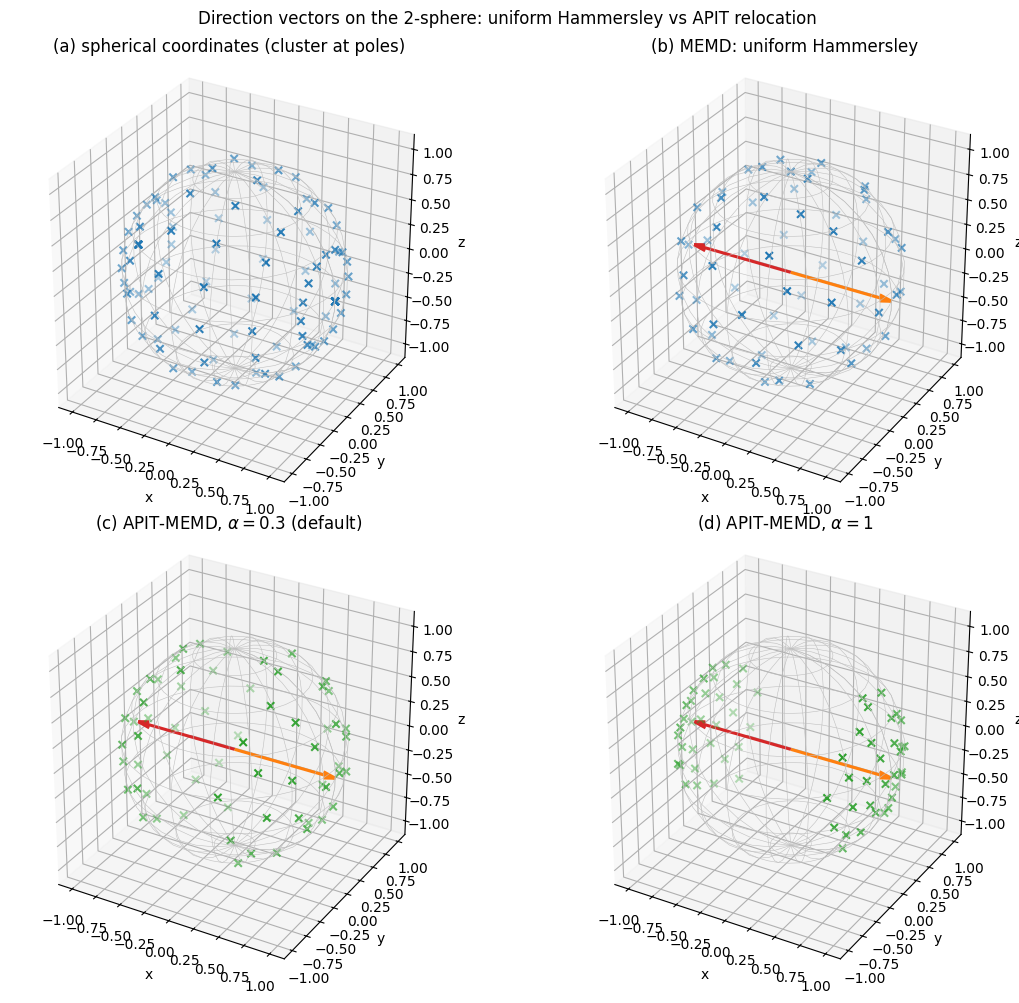

In [3]:
def _draw_sphere(ax, pts, title, pc=None, color="C0"):
    u = np.linspace(0.0, 2.0 * np.pi, 36)
    v = np.linspace(0.0, np.pi, 18)
    xs = np.outer(np.cos(u), np.sin(v)).T
    ys = np.outer(np.sin(u), np.sin(v)).T
    zs = np.outer(np.ones_like(u), np.cos(v)).T
    ax.plot_wireframe(xs, ys, zs, color="0.75", linewidth=0.4, rstride=2, cstride=2)
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=color, marker="x", s=28)
    if pc is not None:
        origin = np.zeros(3)
        ax.quiver(*origin, *pc, color="C3", lw=2.2, arrow_length_ratio=0.12)
        ax.quiver(*origin, *(-pc), color="C1", lw=2.2, arrow_length_ratio=0.12)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))


fig = plt.figure(figsize=(12, 10))
axes = [fig.add_subplot(2, 2, k, projection="3d") for k in range(1, 5)]
_draw_sphere(axes[0], grid_pts, "(a) spherical coordinates (cluster at poles)")
_draw_sphere(axes[1], uniform, "(b) MEMD: uniform Hammersley", pc=pc1, color="C0")
_draw_sphere(
    axes[2], adapted[0.3], r"(c) APIT-MEMD, $\alpha=0.3$ (default)", pc=pc1, color="C2"
)
_draw_sphere(axes[3], adapted[1.0], r"(d) APIT-MEMD, $\alpha=1$", pc=pc1, color="C2")
fig.suptitle(
    "Direction vectors on the 2-sphere: uniform Hammersley vs APIT relocation",
    y=0.98,
)
plt.tight_layout()
plt.show()

Panel (a) is the angular grid from the MEMD paper: equal steps in
\((\theta_1, \theta_2)\) pile up at the poles and are **not** used inside
either algorithm.  Panel (b) is the Hammersley set of MEMD; the red / orange
arrows are \(\pm\mathrm{PC}_1\).  Panels (c) and (d) are the APIT-relocated
sets.  At \(\alpha = 0.3\) the cloud is still spread over the sphere but
denser along the imbalance axis; at \(\alpha = 1\) it is strongly
importance-sampled.  That is the only geometric difference between MEMD and
APIT-MEMD — envelopes, sifting and the two stop criteria are the same.


## 3. Algorithm (what changes relative to MEMD)

Let \(s(t) \in \mathbb{R}^n\) be the current residue.  MEMD estimates the
local mean as the average of multivariate envelopes obtained from projections
\(\langle s, x^{\theta_k} \rangle\), \(k = 1,\ldots,K\), with \(\{x^{\theta_k}\}\)
a Hammersley net on the sphere.

APIT-MEMD inserts one extra step **before** those projections, at every
sifting iteration (MATLAB `nonuniform_nD_2`):

\[
C = \mathrm{cov}\bigl(s(t)\bigr),\qquad
C = V\Lambda V^\top,\qquad
v_1 = V_{\cdot,1}.
\]

The \(K/2\) Hammersley vectors nearest \(v_1\) are shifted by \(\alpha v_1\);
the \(K/2\) nearest \(-v_1\) are shifted by \(-\alpha v_1\); each is
re-normalised.  Higher principal axes are **not** used in this MATLAB
release (`N(1)=ndir/2`, `N(2:end)=0`).

PySDKit layout matches MEMD: input `(n_channels, n_samples)`, output
`(n_imfs, n_samples, n_channels)` with the last slice the residue.


## 4. Power-imbalanced trivariate tones

A shared 4 Hz oscillation lives on every channel, but channel 0 is ten times
stronger than the others (the situation MEMD's uniform net handles poorly
unless `n_dir` is large).  We decompose with a **modest** `n_dir=16` — the
regime where the paper reports the largest APIT gain.


In [4]:
n_samples = 400
fs = 200.0
t = np.arange(n_samples) / fs
shared = np.cos(2 * np.pi * 4 * t)
ch0 = 10.0 * (shared + 0.4 * np.cos(2 * np.pi * 18 * t))
ch1 = 0.8 * shared + 0.5 * np.sin(2 * np.pi * 11 * t)
ch2 = 0.5 * shared + 0.7 * np.cos(2 * np.pi * 18 * t)
signal = np.vstack([ch0, ch1, ch2])

apit = APITMEMD(n_dir=16, max_iter=200, alpha=0.3)
imfs = apit.fit_transform(signal)
err = np.max(np.abs(imfs.sum(axis=0).T - signal))
print("input", signal.shape, "APIT-MEMD IMFs", imfs.shape)
print("reconstruction max abs error", err)

memd = MEMD(n_dir=16, max_iter=200)
imfs_memd = memd.fit_transform(signal)
print("MEMD IMFs", imfs_memd.shape)
print(apit)

input (3, 400) APIT-MEMD IMFs (3, 400, 3)
reconstruction max abs error 1.7763568394002505e-15
MEMD IMFs (3, 400, 3)
Adaptive-Projection Intrinsically Transformed MEMD (APIT-MEMD)


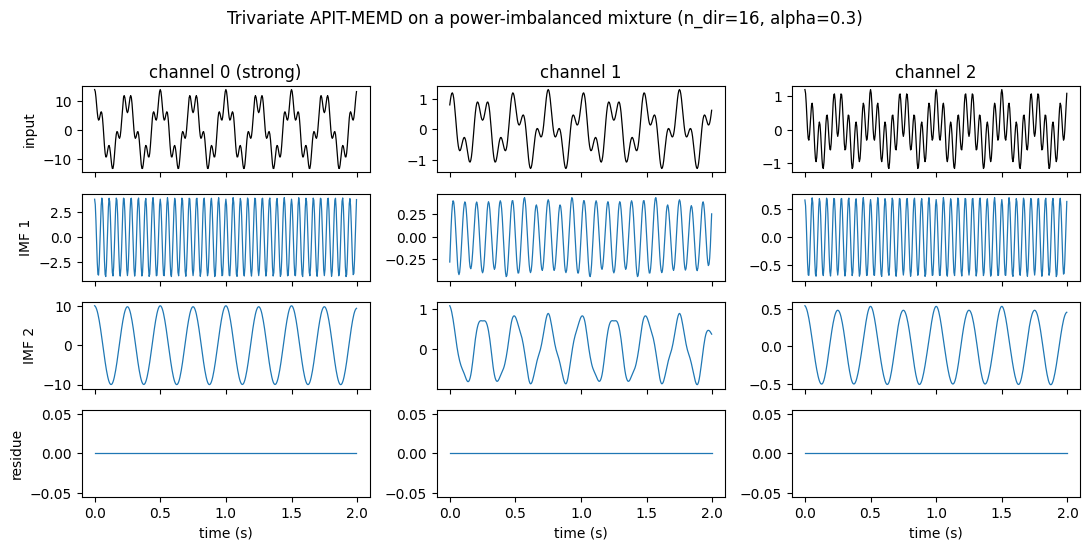

In [5]:
n_imfs = imfs.shape[0]
fig, axes = plt.subplots(n_imfs + 1, 3, figsize=(11, 1.35 * (n_imfs + 1)), sharex=True)
labels = ["channel 0 (strong)", "channel 1", "channel 2"]
for c in range(3):
    axes[0, c].plot(t, signal[c], color="k", lw=0.9)
    axes[0, c].set_title(labels[c])
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_imfs):
        axes[k + 1, c].plot(t, imfs[k, :, c], lw=0.9)
        if c == 0:
            ylab = "residue" if k == n_imfs - 1 else "IMF {}".format(k + 1)
            axes[k + 1, c].set_ylabel(ylab)
        if k == n_imfs - 1:
            axes[k + 1, c].set_xlabel("time (s)")
fig.suptitle(
    "Trivariate APIT-MEMD on a power-imbalanced mixture (n_dir=16, alpha=0.3)",
    y=1.01,
)
plt.tight_layout()
plt.show()

The 4 Hz tone is common to all three channels, so mode alignment should put
it in the **same IMF index** on every column.  Channel 0's extra 18 Hz
energy is what tilts \(\mathrm{PC}_1\); APIT spends more projections there
and typically needs fewer sifting directions than MEMD to keep the shared
scale aligned.


## 5. Trajectory, PC1 and a single adaptive projection

Same idea as the MEMD notebook: the 3-D path of a short segment, the
direction set, and one scalar projection whose extrema drive the envelopes.
Here the arrows are **APIT-relocated** (green) rather than uniform Hammersley.


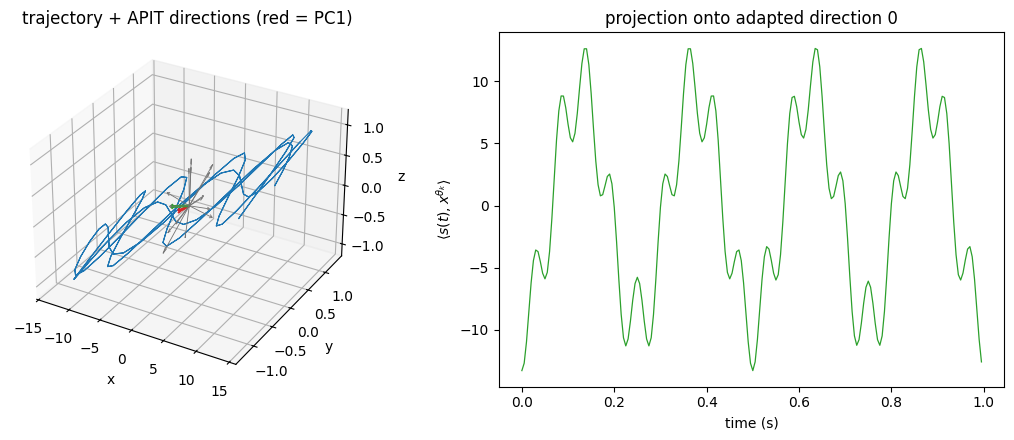

In [6]:
dirs = apit.adaptive_directions(signal.T, 3)
seg = signal[:, :200].T
k_show = 0
proj = seg @ dirs[k_show]

fig = plt.figure(figsize=(11, 4.5))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")
ax3.plot(seg[:, 0], seg[:, 1], seg[:, 2], color="C0", lw=0.8)
origin = np.zeros(3)
pc = first_principal_component(signal.T)
ax3.quiver(*origin, *1.2 * pc, color="C3", lw=2.2, arrow_length_ratio=0.12)
for vec in dirs:
    ax3.quiver(*origin, *0.8 * vec, color="0.45", lw=0.6, arrow_length_ratio=0.12)
ax3.quiver(*origin, *1.0 * dirs[k_show], color="C2", lw=2.0, arrow_length_ratio=0.12)
ax3.set_title("trajectory + APIT directions (red = PC1)")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")

axp = fig.add_subplot(1, 2, 2)
axp.plot(t[:200], proj, color="C2", lw=0.9)
axp.set_title("projection onto adapted direction {}".format(k_show))
axp.set_xlabel("time (s)")
axp.set_ylabel(r"$\langle s(t), x^{\theta_k}\rangle$")
plt.tight_layout()
plt.show()

## 6. Packaged supplement: cooperative SSVEP (`data_section_3a.mat`)

Section 3a is a two-person SSVEP record sampled at 1200 Hz
(`y1`, `y2`, `s1`, `s2`, length 286801).  That file is several megabytes, so
PySDKit ships only the **first 2048 samples** (~1.7 s) as
`pysdkit/data/apitmemd_section_3a.npy`, layout `(4, 2048)`.  The two remaining
supplement records (hexavariate P300 and single-shot P300 trials) are packed
in full in the next sections.


snippet (4, 2048) fs 1200.0 duration 1.7058333333333333 s
IMFs (2, 2048, 4) recon max abs error 0.0


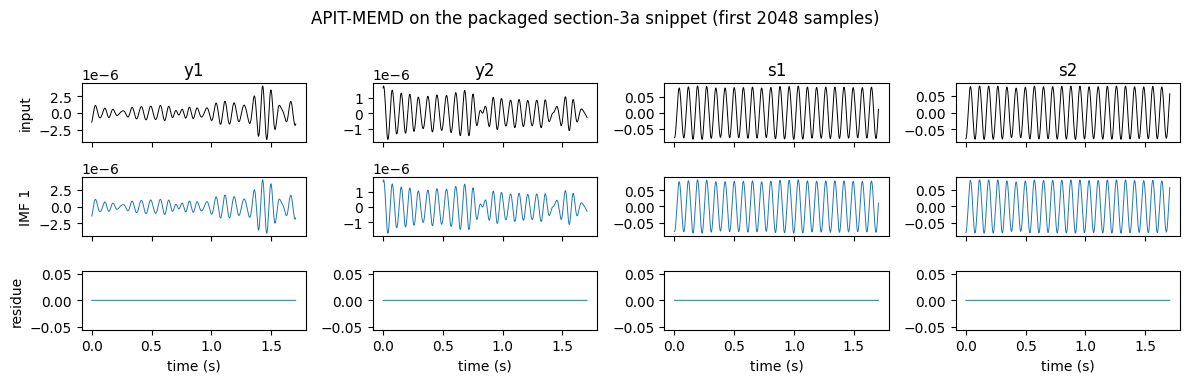

In [7]:
demo = load_apitmemd_section_3a()
x4 = demo["signal"]
t4 = demo["t"]
fs4 = demo["fs"]
print("snippet", x4.shape, "fs", fs4, "duration", t4[-1], "s")

apit4 = APITMEMD(n_dir=16, max_iter=120, alpha=0.3)
imfs4 = apit4.fit_transform(x4)
err4 = np.max(np.abs(imfs4.sum(axis=0).T - x4))
print("IMFs", imfs4.shape, "recon max abs error", err4)

n_show = min(imfs4.shape[0], 5)
names = ["y1", "y2", "s1", "s2"]
fig, axes = plt.subplots(n_show + 1, 4, figsize=(12, 1.25 * (n_show + 1)), sharex=True)
for c in range(4):
    axes[0, c].plot(t4, x4[c], color="k", lw=0.7)
    axes[0, c].set_title(names[c])
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_show):
        axes[k + 1, c].plot(t4, imfs4[k, :, c], lw=0.7)
        if c == 0:
            if k == imfs4.shape[0] - 1:
                ylab = "residue"
            else:
                ylab = "IMF {}".format(k + 1)
            axes[k + 1, c].set_ylabel(ylab)
        if k == n_show - 1:
            axes[k + 1, c].set_xlabel("time (s)")
fig.suptitle(
    "APIT-MEMD on the packaged section-3a snippet (first 2048 samples)",
    y=1.01,
)
plt.tight_layout()
plt.show()

## 7. Packaged supplement: hexavariate P300 (`data_section_2b.mat`)

Paper §2(b) reconstructs real-world P300 EEG in the presence of **power
imbalance** across electrodes.  The supplement stores six channels
(`ch1`–`ch6`) of length 360 at 1200 Hz (0.3 s).  Channels 1–3 / 4–6 follow
the two-subject grouping used in that example.  The record is small enough
to ship in full as `apitmemd_section_2b.npy`, layout `(6, 360)`.


section 2b (6, 360) fs 1200.0 duration 0.2991666666666667 s
per-channel RMS [4.75074002e-06 4.00426207e-06 3.33144212e-06 2.37577160e-06
 1.47019222e-06 2.91384924e-06]
IMFs (5, 360, 6) recon max abs error 1.6940658945086007e-21


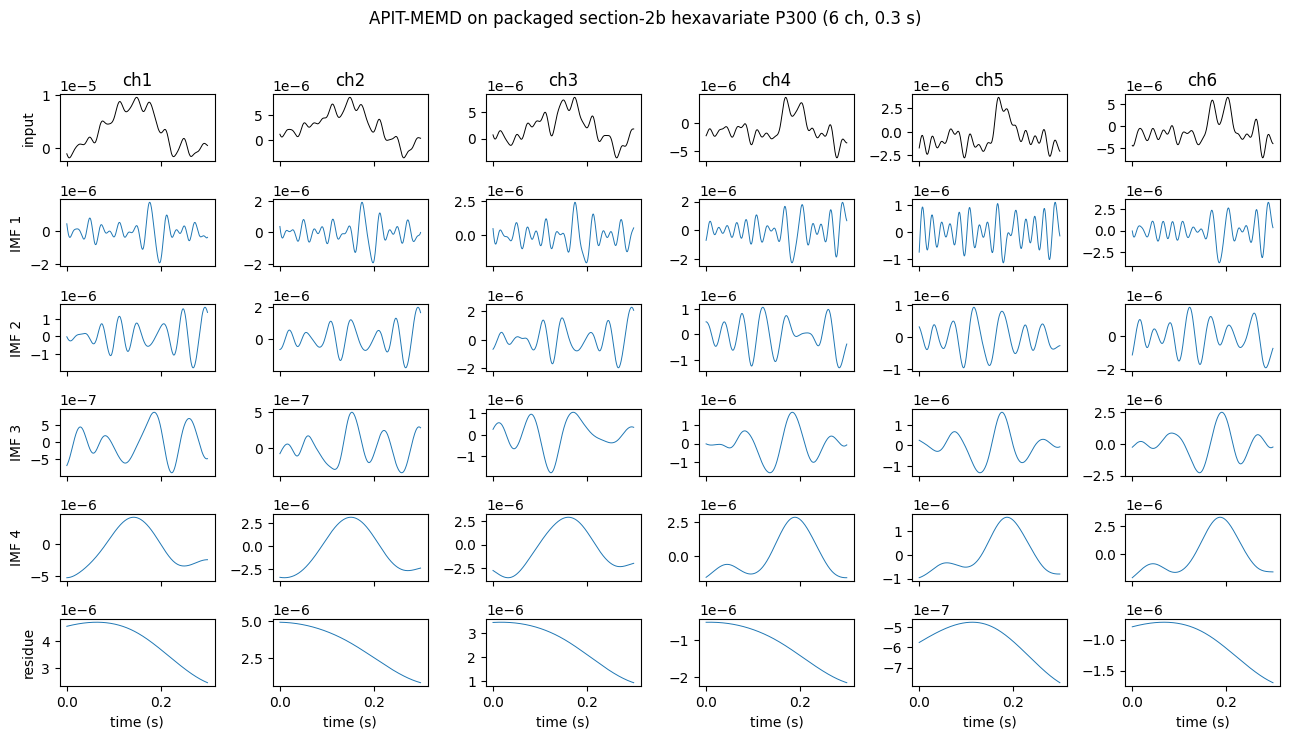

In [8]:
demo2b = load_apitmemd_section_2b()
x6 = demo2b["signal"]
t6 = demo2b["t"]
print("section 2b", x6.shape, "fs", demo2b["fs"], "duration", t6[-1], "s")
print("per-channel RMS", np.sqrt(np.mean(x6**2, axis=1)))

apit6 = APITMEMD(n_dir=16, max_iter=120, alpha=0.3)
imfs6 = apit6.fit_transform(x6)
err6 = np.max(np.abs(imfs6.sum(axis=0).T - x6))
print("IMFs", imfs6.shape, "recon max abs error", err6)

n_show = min(imfs6.shape[0], 5)
names6 = ["ch{}".format(i + 1) for i in range(6)]
fig, axes = plt.subplots(n_show + 1, 6, figsize=(13, 1.2 * (n_show + 1)), sharex=True)
for c in range(6):
    axes[0, c].plot(t6, x6[c], color="k", lw=0.7)
    axes[0, c].set_title(names6[c])
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_show):
        axes[k + 1, c].plot(t6, imfs6[k, :, c], lw=0.7)
        if c == 0:
            ylab = "residue" if k == imfs6.shape[0] - 1 else "IMF {}".format(k + 1)
            axes[k + 1, c].set_ylabel(ylab)
        if k == n_show - 1:
            axes[k + 1, c].set_xlabel("time (s)")
fig.suptitle("APIT-MEMD on packaged section-2b hexavariate P300 (6 ch, 0.3 s)", y=1.02)
plt.tight_layout()
plt.show()

The RMS values decrease from `ch1` to `ch5`: that is exactly the power
imbalance APIT-MEMD is designed for.  The slow P300-scale deflection should
appear as a **common IMF index** across the six electrodes, with the last
row the residue.


## 8. Packaged supplement: single-shot P300 trials (`data_section_3b.mat`)

Paper §3(b) detects **single-shot** P300 from a pair of subjects (no
trial-averaging).  The supplement stores ten hexavariate responses
(`response1`–`response10`, each `ch1`–`ch6`) of length 240 at 1200 Hz
(0.2 s).  Packed as `apitmemd_section_3b.npy` with layout `(10, 6, 240)`.
The figure below shows all ten raw trials on `ch1`, then the APIT-MEMD of
the first trial.


section 3b (10, 6, 240) fs 1200.0 duration 0.19916666666666666 s


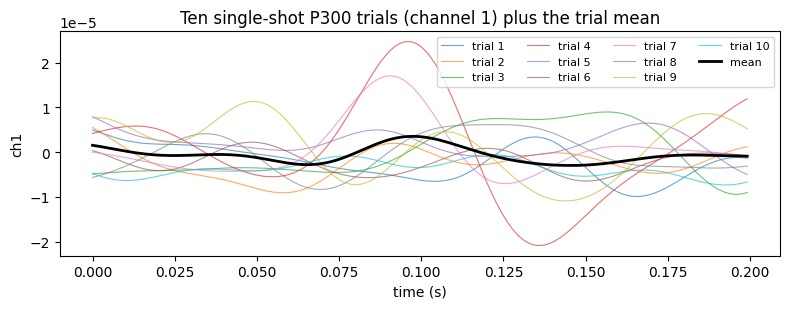

trial 1 IMFs (3, 240, 6) recon max abs error 1.6940658945086007e-21


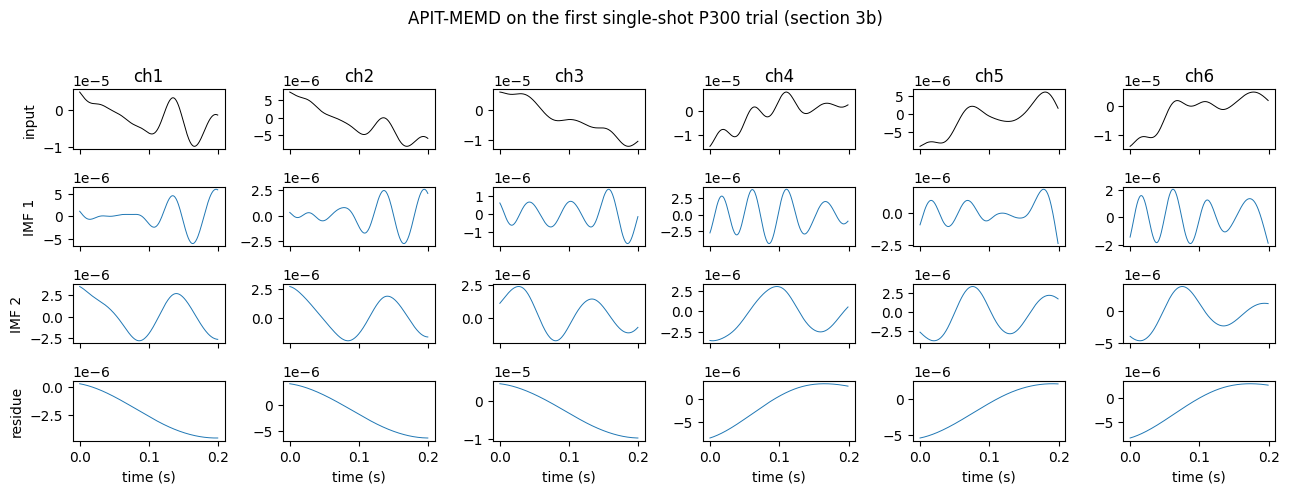

In [9]:
demo3b = load_apitmemd_section_3b()
trials = demo3b["signal"]
t_p300 = demo3b["t"]
print("section 3b", trials.shape, "fs", demo3b["fs"], "duration", t_p300[-1], "s")

fig, ax = plt.subplots(figsize=(8, 3.2))
for i in range(trials.shape[0]):
    ax.plot(t_p300, trials[i, 0], lw=0.8, alpha=0.65, label="trial {}".format(i + 1))
ax.plot(t_p300, trials[:, 0].mean(axis=0), color="k", lw=2.0, label="mean")
ax.set_xlabel("time (s)")
ax.set_ylabel("ch1")
ax.set_title("Ten single-shot P300 trials (channel 1) plus the trial mean")
ax.legend(ncol=4, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

x_trial = trials[0]
apit_p300 = APITMEMD(n_dir=16, max_iter=120, alpha=0.3)
imfs_p300 = apit_p300.fit_transform(x_trial)
err_p300 = np.max(np.abs(imfs_p300.sum(axis=0).T - x_trial))
print("trial 1 IMFs", imfs_p300.shape, "recon max abs error", err_p300)

n_show = min(imfs_p300.shape[0], 5)
fig, axes = plt.subplots(n_show + 1, 6, figsize=(13, 1.2 * (n_show + 1)), sharex=True)
for c in range(6):
    axes[0, c].plot(t_p300, x_trial[c], color="k", lw=0.7)
    axes[0, c].set_title("ch{}".format(c + 1))
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_show):
        axes[k + 1, c].plot(t_p300, imfs_p300[k, :, c], lw=0.7)
        if c == 0:
            ylab = "residue" if k == imfs_p300.shape[0] - 1 else "IMF {}".format(k + 1)
            axes[k + 1, c].set_ylabel(ylab)
        if k == n_show - 1:
            axes[k + 1, c].set_xlabel("time (s)")
fig.suptitle("APIT-MEMD on the first single-shot P300 trial (section 3b)", y=1.02)
plt.tight_layout()
plt.show()

## 9. Practical notes

- **`n_dir`.**  As in MEMD, a rule of thumb is at least twice the number of
  channels.  APIT-MEMD is specifically meant to remain useful when you *cannot*
  afford a huge net; start around 8–32 for \(C=3\)–\(6\).
- **`alpha`.**  Suggested range \([0, 1]\).  Use `0` to recover MEMD-like
  behaviour; raise it when one (or a few) channels dominate.  The MATLAB
  default `0.3` is a reasonable first try.
- **Stop criteria.**  `"stop"` (Rilling, default `stop_vec=[0.075, 0.75, 0.075]`)
  and `"fix_h"` (Huang, `stop_cnt=2`) are identical to MEMD.
- **Channel count.**  MATLAB `Max_channels = 32` (the error message still
  says 16).  Univariate / bivariate records should use `EMD` / bivariate EMD.
- **Reconstruction.**  Summing IMFs along axis 0, including the last residue
  slice, recovers the (oriented) input up to rounding.
- **Packaged data.**  `load_apitmemd_section_2b` (hexavariate P300),
  `load_apitmemd_section_3a` (SSVEP snippet) and
  `load_apitmemd_section_3b` (ten single-shot P300 trials).
